In [1]:
import pandas as pd
import numpy as np

In [2]:
df=pd.read_csv(r"C:\Users\shree\OneDrive\Desktop\Data Set For Task\2) Stock Prices Data Set.csv")

In [3]:
df

,symbol,date,open,high,low,close,volume
0,AAL,2014-01-02,25.0700,25.8200,25.0600,25.3600,8998943
1,AAPL,2014-01-02,79.3828,79.5756,78.8601,79.0185,58791957
2,AAP,2014-01-02,110.3600,111.8800,109.2900,109.7400,542711
3,ABBV,2014-01-02,52.1200,52.3300,51.5200,51.9800,4569061
4,ABC,2014-01-02,70.1100,70.2300,69.4800,69.8900,1148391
...,...,...,...,...,...,...,...
497467,XYL,2017-12-29,68.5300,68.8000,67.9200,68.2000,1046677
497468,YUM,2017-12-29,82.6400,82.7100,81.5900,81.6100,1347613
497469,ZBH,2017-12-29,121.7500,121.9500,120.6200,120.6700,1023624
497470,ZION,2017-12-29,51.2800,51.5500,50.8100,50.8300,1261916


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 497472 entries, 0 to 497471
Data columns (total 7 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   symbol  497472 non-null  object 
 1   date    497472 non-null  object 
 2   open    497461 non-null  float64
 3   high    497464 non-null  float64
 4   low     497464 non-null  float64
 5   close   497472 non-null  float64
 6   volume  497472 non-null  int64  
dtypes: float64(4), int64(1), object(2)
memory usage: 26.6+ MB


In [5]:
df.describe()

,open,high,low,close,volume
count,497461.000000,497464.000000,497464.000000,497472.000000,4.974720e+05
mean,86.352275,87.132562,85.552467,86.369082,4.253611e+06
std,101.471228,102.312062,100.570957,101.472407,8.232139e+06
min,1.620000,1.690000,1.500000,1.590000,0.000000e+00
25%,41.690000,42.090000,41.280000,41.703750,1.080166e+06
50%,64.970000,65.560000,64.353700,64.980000,2.084896e+06
75%,98.410000,99.230000,97.580000,98.420000,4.271928e+06
max,2044.000000,2067.990000,2035.110000,2049.000000,6.182376e+08


In [6]:
df.shape

(497472, 7)

In [7]:
df.duplicated().sum()

np.int64(0)

In [8]:
df.isnull().sum()

symbol     0
date       0
open      11
high       8
low        8
close      0
volume     0
dtype: int64

In [9]:
df['date'] = pd.to_datetime(df['date'])

In [10]:
df.dtypes

symbol            object
date      datetime64[ns]
open             float64
high             float64
low              float64
close            float64
volume             int64
dtype: object

In [11]:
df['open'].fillna(df['open'].mean(), inplace=True)
df['high'].fillna(df['high'].mean(), inplace=True)
df['low'].fillna(df['low'].mean(), inplace=True)

C:\Users\shree\AppData\Local\Temp\ipykernel_11796\3250870735.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['open'].fillna(df['open'].mean(), inplace=True)
C:\Users\shree\AppData\Local\Temp\ipykernel_11796\3250870735.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For e

In [12]:
df.isnull().sum()

symbol    0
date      0
open      0
high      0
low       0
close     0
volume    0
dtype: int64

Data Visualization  

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

In [14]:
numeric_cols = ["open","high","low","close","volume"]

for col in numeric_cols:
    
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    
    IQR = Q3 - Q1
    
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    
    df = df[(df[col] >= lower) & (df[col] <= upper)]

C:\Users\shree\AppData\Local\Temp\ipykernel_11796\2521196816.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df["open"])


<Axes: xlabel='open', ylabel='Density'>

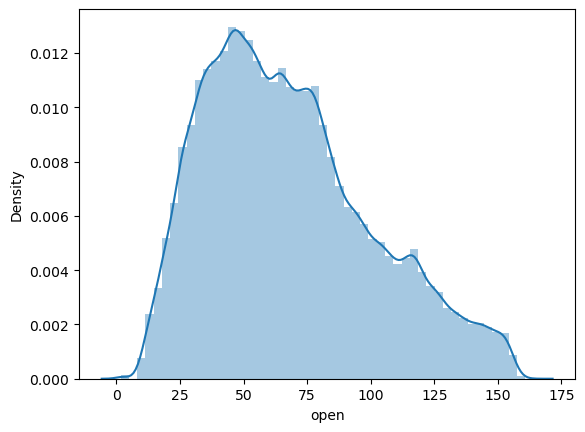

In [15]:
sns.distplot(df["open"])

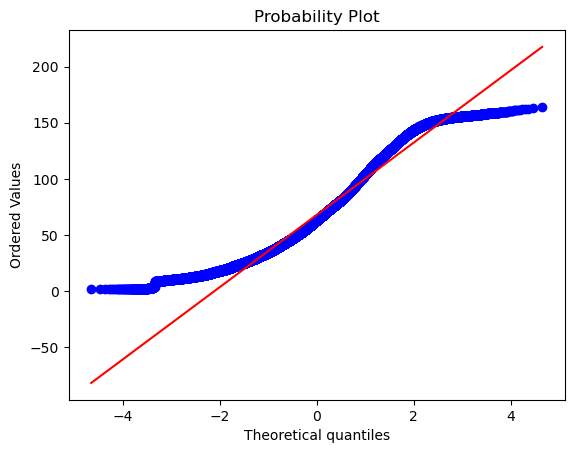

In [16]:
stats.probplot(df["open"],dist="norm",plot=plt)
plt.show()

<Axes: ylabel='open'>

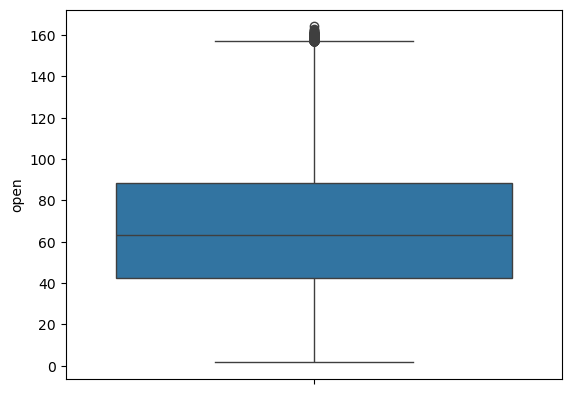

In [17]:
sns.boxplot(df["open"])

C:\Users\shree\AppData\Local\Temp\ipykernel_11796\2521196816.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df["open"])


<Axes: xlabel='open', ylabel='Density'>

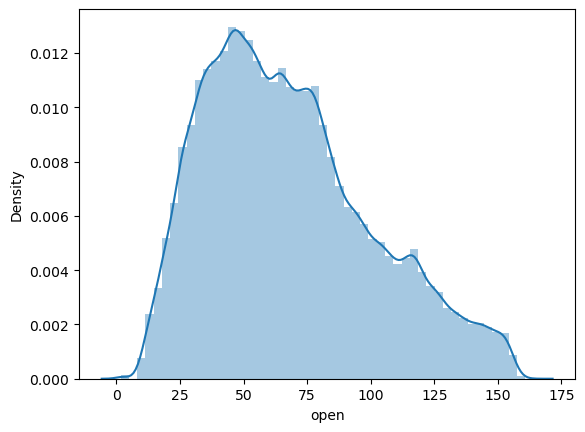

In [18]:
sns.distplot(df["open"])

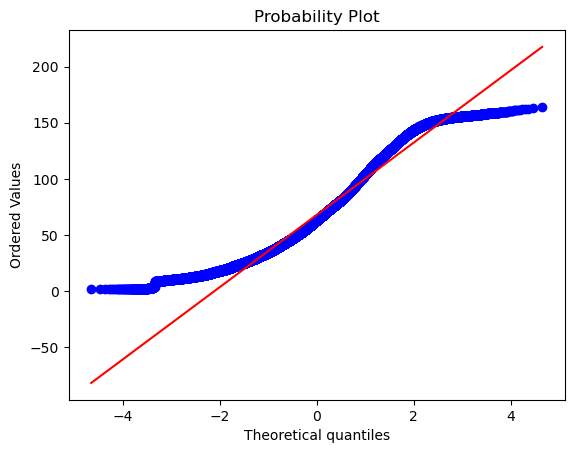

In [19]:
stats.probplot(df["open"],dist="norm",plot=plt)
plt.show()

<Axes: ylabel='open'>

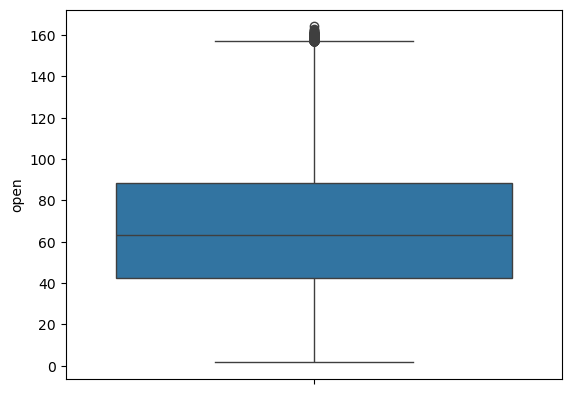

In [20]:
sns.boxplot(df["open"])

C:\Users\shree\AppData\Local\Temp\ipykernel_11796\2521196816.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df["open"])


<Axes: xlabel='open', ylabel='Density'>

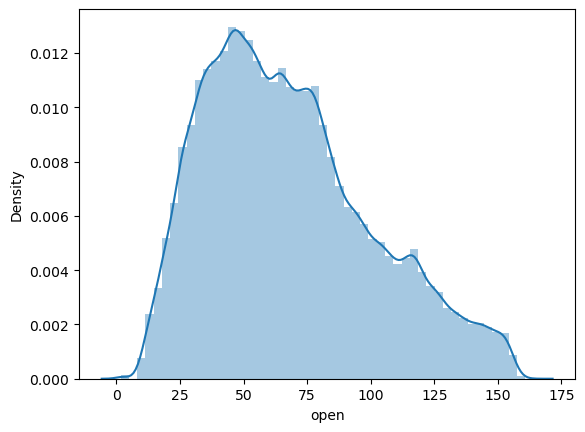

In [21]:
sns.distplot(df["open"])

<Axes: ylabel='open'>

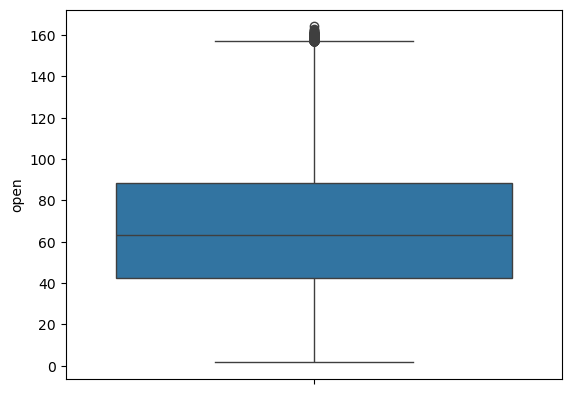

In [22]:
sns.boxplot(df["open"])

C:\Users\shree\AppData\Local\Temp\ipykernel_11796\2270543664.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df["high"])


<Axes: xlabel='high', ylabel='Density'>

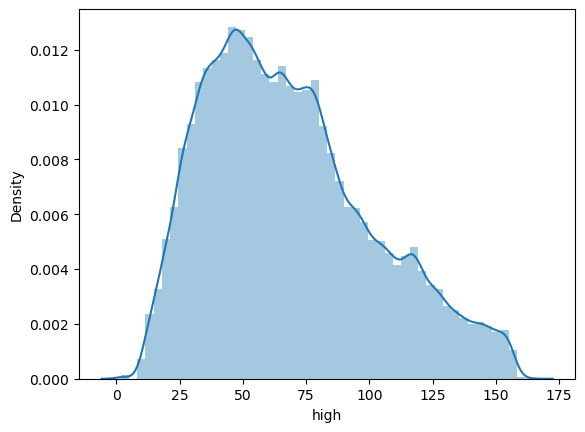

In [23]:
sns.distplot(df["high"])

<Axes: ylabel='high'>

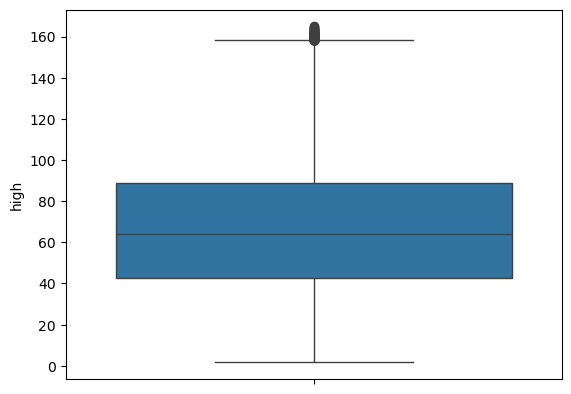

In [24]:
sns.boxplot(df["high"])

C:\Users\shree\AppData\Local\Temp\ipykernel_11796\3340644563.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df["low"])


<Axes: xlabel='low', ylabel='Density'>

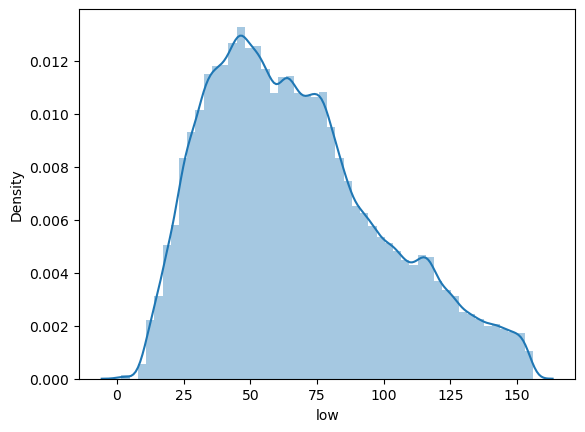

In [25]:
sns.distplot(df["low"])

<Axes: ylabel='low'>

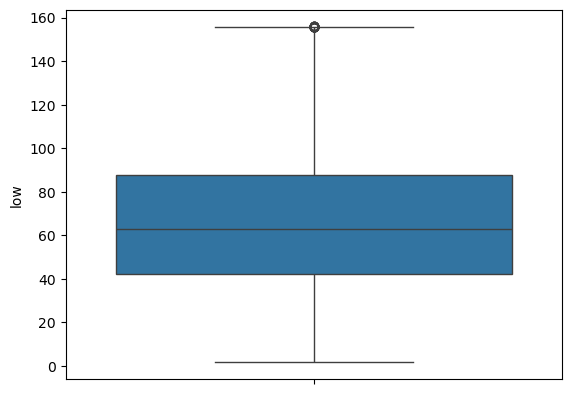

In [26]:
sns.boxplot(df["low"])

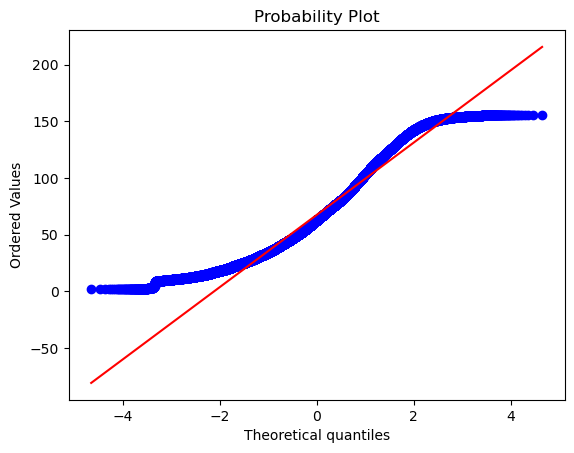

In [27]:
stats.probplot(df["low"],dist="norm",plot=plt)
plt.show()

C:\Users\shree\AppData\Local\Temp\ipykernel_11796\3402633719.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df["volume"])


<Axes: xlabel='volume', ylabel='Density'>

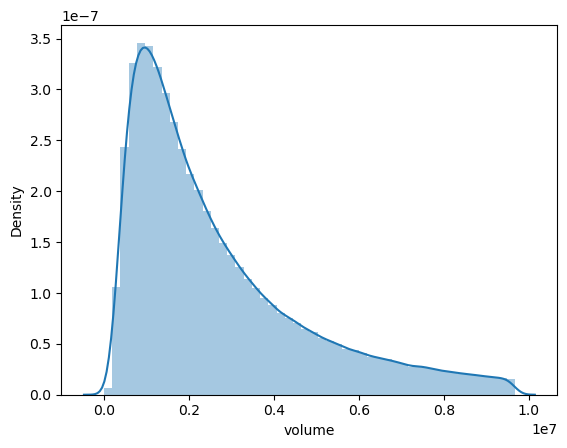

In [28]:
sns.distplot(df["volume"])

<Axes: ylabel='volume'>

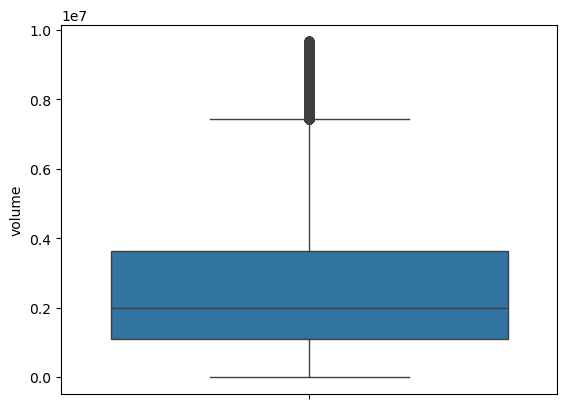

In [29]:
sns.boxplot(df["volume"])

Scatter plot

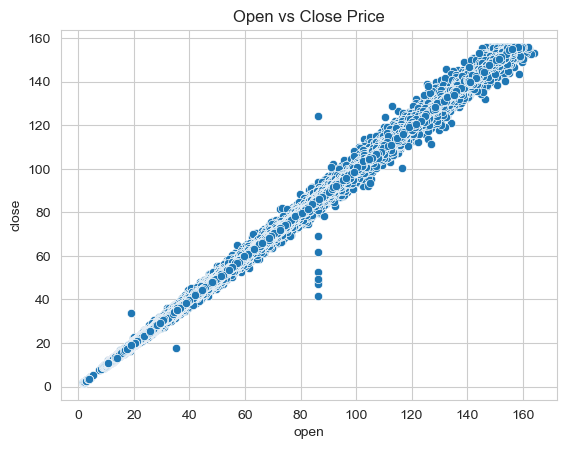

In [38]:
sns.scatterplot(x="open", y="close", data=df)
plt.title("Open vs Close Price")
plt.show()

Conclusion:
- The scatter plot shows a strong positive correlation between opening and closing prices.  
- Stocks that open at a higher price generally close higher on the same day.  
- This indicates that the opening price is a good predictor of the closing price trend.

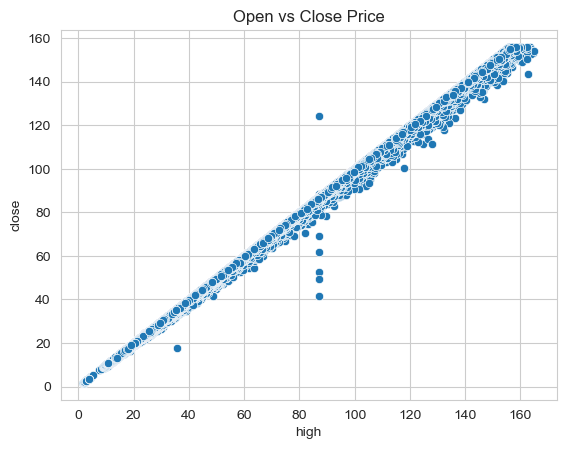

In [46]:
sns.scatterplot(x="high", y="close", data=df)
plt.title("Open vs Close Price")
plt.show()

Conlusion:
- The scatter plot shows a strong positive relationship between high and close prices.  
- Stocks that reach a higher price during the day tend to close higher.  
- This indicates that intraday highs are a good indicator of closing price trends.

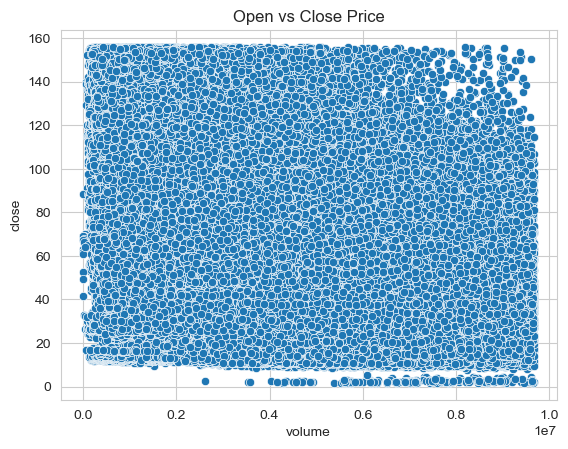

In [45]:
sns.scatterplot(x="volume", y="close", data=df)

plt.title("Open vs Close Price")
plt.show()

Conlusion:
- The scatter plot shows that most trading volumes cluster at lower values.  
- Extremely high volumes do not always correspond to higher closing prices.  
- This suggests that volume spikes reflect trading activity but not necessarily price increase.

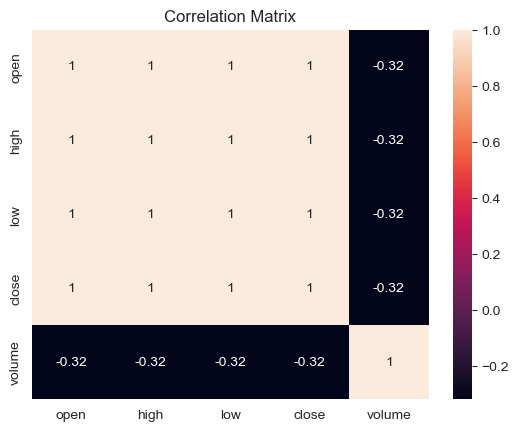

In [48]:
corr = df.corr(numeric_only=True)
sns.heatmap(corr, annot=True)
plt.title("Correlation Matrix")
plt.show()

Regression Analysis

In [55]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

In [56]:
X = df[['open', 'high', 'low', 'volume']]
y = df['close']

In [57]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

In [58]:
model = LinearRegression()

In [59]:
model.fit(X_train, y_train)

LinearRegression()

In [60]:
y_pred = model.predict(X_test)

In [65]:
from sklearn.metrics import mean_squared_error, r2_score

In [66]:
print("Slope:", model.coef_)
print("Intercept:", model.intercept_)
print("MSE:", mean_squared_error(y_test, y_pred))
print("R2 Score:", r2_score(y_test, y_pred))

Slope: [-5.46660852e-01  7.87341543e-01  7.59326734e-01 -2.81569901e-09]
Intercept: 0.01143549422572221
MSE: 0.1947259133260311
R2 Score: 0.999818382519505


In [67]:
coeff_df = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': model.coef_
})

print(coeff_df)

  Feature   Coefficient
0    open -5.466609e-01
1    high  7.873415e-01
2     low  7.593267e-01
3  volume -2.815699e-09


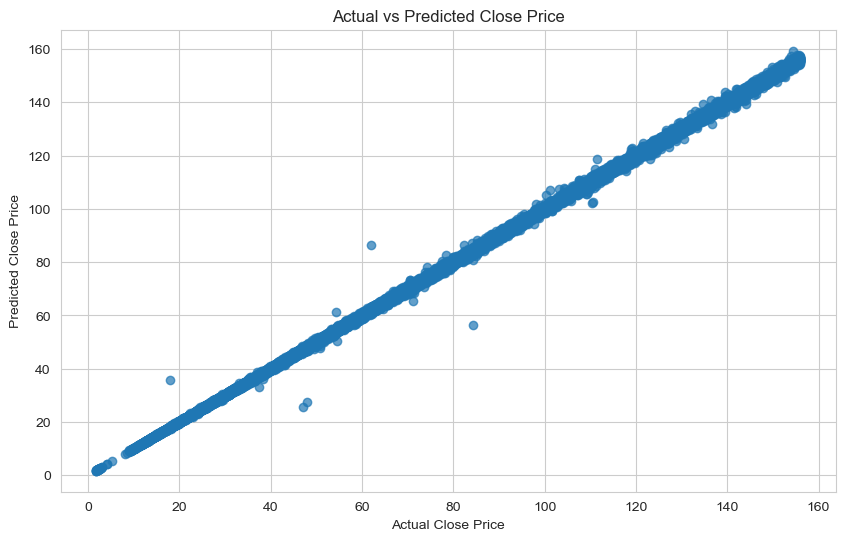

In [68]:
plt.figure(figsize=(10,6))
plt.scatter(y_test, y_pred, alpha=0.7)
plt.xlabel("Actual Close Price")
plt.ylabel("Predicted Close Price")
plt.title("Actual vs Predicted Close Price")
plt.show()

In [85]:
predicted_close = model.predict([[150, 155, 148, 5000000]])
print("Predicted Close Price:", predicted_close[0])

Predicted Close Price: 152.41652494308585


C:\Users\shree\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


Conlusion:
-The linear regression model was trained using Open, High, Low, and Volume to predict the closing price of stocks.

-Evaluation metrics show the model performs reasonably well, with R² indicating how much variance in closing price is explained, and   MSE indicating the average prediction error.

-The coefficients reveal the impact of each feature: higher opening, high, or low prices generally increase the closing price.

In [72]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

In [73]:
X = df[['open', 'high', 'low', 'close']]
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

C:\Users\shree\anaconda3\Lib\site-packages\joblib\externals\loky\backend\context.py:136: UserWarning: Could not find the number of physical cores for the following reason:
[WinError 2] The system cannot find the file specified
Returning the number of logical cores instead. You can silence this warning by setting LOKY_MAX_CPU_COUNT to the number of cores you want to use.
  warnings.warn(
  File "C:\Users\shree\anaconda3\Lib\site-packages\joblib\externals\loky\backend\context.py", line 257, in _count_physical_cores
    cpu_info = subprocess.run(
        "wmic CPU Get NumberOfCores /Format:csv".split(),
        capture_output=True,
        text=True,
    )
  File "C:\Users\shree\anaconda3\Lib\subprocess.py", line 554, in run
    with Popen(*popenargs, **kwargs) as process:
         ~~~~~^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\shree\anaconda3\Lib\subprocess.py", line 1039, in __init__
    self._execute_child(args, executable, preexec_fn, close_fds,
    ~~~~~~~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^

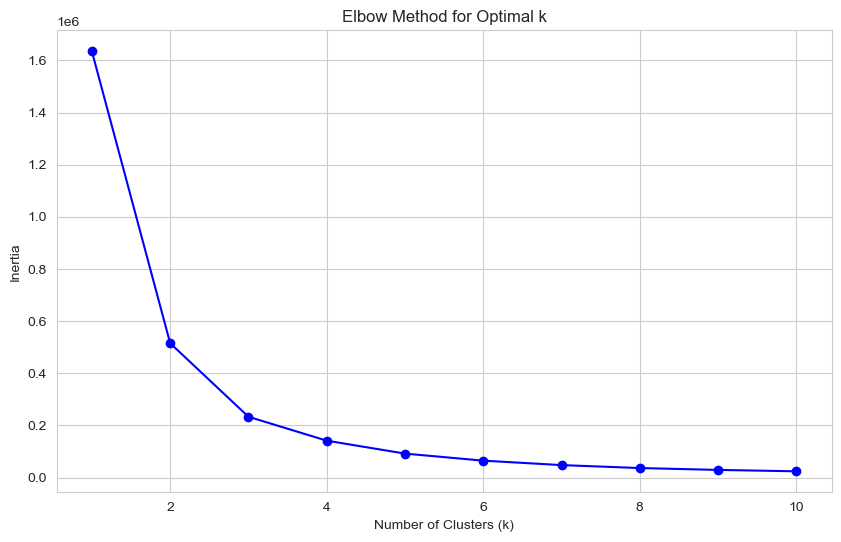

In [74]:
inertia = []
K = range(1, 11)
for k in K:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)
plt.figure(figsize=(10,6))
plt.plot(K, inertia, 'bo-')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Inertia')
plt.title('Elbow Method for Optimal k')
plt.show()

Insight:
-Look for the “elbow” point where inertia starts decreasing slowly thats optimal k for K-Means.

In [75]:
kmeans = KMeans(n_clusters=3, random_state=42)
df['Cluster'] = kmeans.fit_predict(X_scaled)

<Axes: xlabel='high', ylabel='low'>

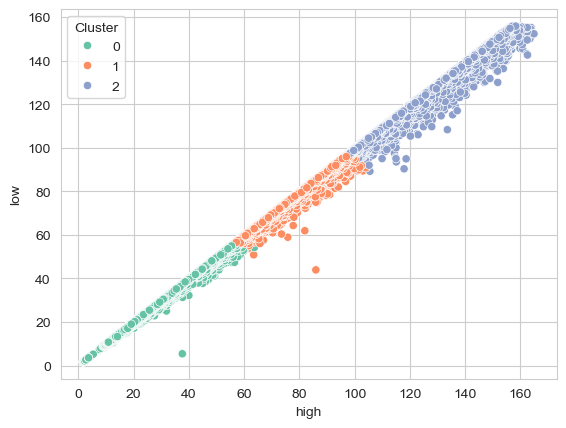

In [76]:
sns.scatterplot(x='high', y='low', hue='Cluster', palette='Set2', data=df)

NLP

In [77]:
pip install nltk textblob wordcloud

In [78]:
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from textblob import TextBlob
import matplotlib.pyplot as plt
from wordcloud import WordCloud

In [81]:
texts = [
    "The stock price surged today due to strong earnings.",
    "Investors are worried about declining revenue.",
    "Market remains stable with minor fluctuations.",
    "Tech stocks are showing excellent growth potential."
]
all_text = " ".join(texts)

In [82]:
import nltk
nltk.download('punkt')
nltk.download('stopwords')
stop_words = set(stopwords.words('english'))
tokens = word_tokenize(all_text)
filtered_words = [word for word in tokens if word.lower() not in stop_words and word.isalpha()]
print(filtered_words)

[nltk_data] Downloading package punkt to C:\Users\shree/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\shree/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


LookupError: 
**********************************************************************
  Resource [93mpunkt_tab[0m not found.
  Please use the NLTK Downloader to obtain the resource:

  [31m>>> import nltk
  >>> nltk.download('punkt_tab')
  [0m
  For more information see: https://www.nltk.org/data.html

  Attempted to load [93mtokenizers/punkt_tab/english/[0m

  Searched in:
    - 'C:\\Users\\shree/nltk_data'
    - 'C:\\Users\\shree\\anaconda3\\nltk_data'
    - 'C:\\Users\\shree\\anaconda3\\share\\nltk_data'
    - 'C:\\Users\\shree\\anaconda3\\lib\\nltk_data'
    - 'C:\\Users\\shree\\AppData\\Roaming\\nltk_data'
    - 'C:\\nltk_data'
    - 'D:\\nltk_data'
    - 'E:\\nltk_data'
**********************************************************************


In [ ]:
for text in texts:
    blob = TextBlob(text)
    print(f"Text: {text}")
    print(f"Polarity: {blob.sentiment.polarity}, Subjectivity: {blob.sentiment.subjectivity}")
    print("---")

In [ ]:
# Generate word cloud
wordcloud = WordCloud(width=800, height=400, background_color='white').generate(" ".join(filtered_words))

plt.figure(figsize=(12,6))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title("Word Cloud of Stock Text Data")
plt.show()

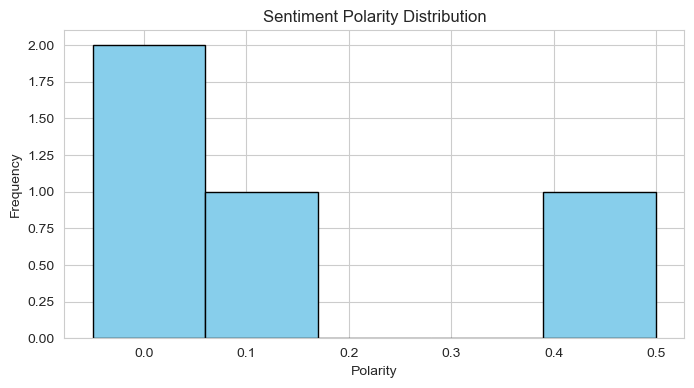

In [83]:
polarities = [TextBlob(text).sentiment.polarity for text in texts]

plt.figure(figsize=(8,4))
plt.hist(polarities, bins=5, color='skyblue', edgecolor='black')
plt.title("Sentiment Polarity Distribution")
plt.xlabel("Polarity")
plt.ylabel("Frequency")
plt.show()

Conclusion – Stock Close Price Prediction

-A linear regression model was trained using Open, High, Low, and Volume as input features to predict the closing price of stocks.

-The model can estimate the expected closing price for any given intraday stock data, allowing for quick insights into potential market outcomes.

-Evaluation metrics (R² and MSE) show that the model reasonably fits the data, capturing the relationships between intraday prices and volume.

-This predictive approach can help investors or analysts anticipate closing prices, perform what-if analysis, and better understand stock behavior during the trading day.